<a href="https://colab.research.google.com/github/aryankhanna1409/sentinel/blob/main/colab%20code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Setup

In [1]:
import torch
print("Torch Version :", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

Torch Version : 2.11.0+cu128
CUDA Available: True
GPU : Tesla T4


In [2]:
!pip install -q ultralytics
!pip install -q opencv-python
!pip install -q matplotlib
!pip install -q seaborn
!pip install -q pandas
!pip install -q pyyaml
!pip install -q tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.6 MB/s eta 0:00:00


In [3]:
import os
import cv2
import yaml
import shutil
import random
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

In [4]:
from ultralytics import YOLO
print("Everything imported successfully.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Everything imported successfully.


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
PROJECT_DIR = "/content/drive/MyDrive/SAR_Project"
folders = ["datasets","datasets/raw","datasets/processed","datasets/yolo","weights","results","notebooks"]
for folder in folders:
    os.makedirs(os.path.join(PROJECT_DIR, folder), exist_ok=True)
print("Folders created.")

Folders created.


In [7]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
IMAGE_SIZE = 640
BATCH_SIZE = 16
EPOCHS = 100
print("Configuration Loaded")

Configuration Loaded


In [ ]:
for root, dirs, files in os.walk(PROJECT_DIR):
    level = root.replace(PROJECT_DIR, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

SAR_Project/
    datasets/
        raw/
        processed/
        yolo/
    weights/
    results/
    notebooks/


##Datasets

###Only run once

In [ ]:
DATASET_ROOT = "/content/drive/MyDrive/SAR_Project/datasets/raw"
os.makedirs(DATASET_ROOT, exist_ok=True)
print(DATASET_ROOT)

/content/drive/MyDrive/SAR_Project/datasets/raw


In [ ]:
!pip -q install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'KGAT_c4cfd37a6e0a47f4aafa88073f429206'}

In [ ]:
os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
import os
os.environ['KAGGLE_USERNAME'] = "aryandkhanna"
os.environ['KAGGLE_KEY'] = "KGAT_c4cfd37a6e0a47f4aafa88073f429206"

In [ ]:
%cd $DATASET_ROOT
!pip -q install gdown kaggle huggingface_hub

/content/drive/MyDrive/SAR_Project/datasets/raw


In [ ]:
CROWDHUMAN_DIR = "/content/drive/MyDrive/SAR_Project/datasets/raw/CrowdHuman"
os.makedirs(CROWDHUMAN_DIR, exist_ok=True)

!kaggle datasets download \
    -d loctran0941/crowdhuman \
    -p "$CROWDHUMAN_DIR" \
    --unzip \
    --force

Dataset URL: https://www.kaggle.com/datasets/loctran0941/crowdhuman
License(s): other
100% 10.1G/10.1G [02:33<00:00, 70.9MB/s]



In [ ]:
%cd /content

!gdown 1sBcAmFqNJmNMBZdMtKmO2X4BRjKPyKMc

/content
Downloading...
From (original): https://drive.google.com/uc?id=1sBcAmFqNJmNMBZdMtKmO2X4BRjKPyKMc
From (redirected): https://drive.google.com/uc?id=1sBcAmFqNJmNMBZdMtKmO2X4BRjKPyKMc&confirm=t&uuid=7d8b75a7-7a44-4d1e-9f27-c9bb5b586fcf
To: /content/kaist-cvpr15.tar
100% 39.0G/39.0G [09:57<00:00, 65.3MB/s]


In [ ]:
!tar -xf kaist-cvpr15.tar

Streaming output truncated to the last 5000 lines.
tar: kaist-cvpr15/annotations-xml-new/set11/V001/I00521.xml: Cannot open: No such file or directory
tar: kaist-cvpr15/annotations-xml-new: Cannot mkdir: No space left on device
tar: kaist-cvpr15/annotations-xml-new/set11/V001/I01144.xml: Cannot open: No such file or directory
tar: kaist-cvpr15/annotations-xml-new: Cannot mkdir: No space left on device
tar: kaist-cvpr15/annotations-xml-new/set11/V001/I00541.xml: Cannot open: No such file or directory
tar: kaist-cvpr15/annotations-xml-new: Cannot mkdir: No space left on device
tar: kaist-cvpr15/annotations-xml-new/set11/V001/I00906.xml: Cannot open: No such file or directory
tar: kaist-cvpr15/annotations-xml-new: Cannot mkdir: No space left on device
tar: kaist-cvpr15/annotations-xml-new/set11/V001/I01314.xml: Cannot open: No such file or directory
tar: kaist-cvpr15/annotations-xml-new: Cannot mkdir: No space left on device
tar: kaist-cvpr15/annotations-xml-new/set11/V001/I00807.xml: Can

In [8]:
!cp -r kaist-cvpr15 /content/drive/MyDrive/SAR_Project/datasets/raw/KAIST

cp: cannot stat 'kaist-cvpr15': No such file or directory


In [9]:
%cd /content/drive/MyDrive/SAR_Project/datasets/raw
!mkdir -p LLVIP
%cd LLVIP
!wget https://huggingface.co/datasets/jsonhash/LLVIP/resolve/main/LLVIP.zip
!unzip LLVIP.zip

/content/drive/MyDrive/SAR_Project/datasets/raw
/content/drive/MyDrive/SAR_Project/datasets/raw/LLVIP
--2026-07-19 08:37:45--  https://huggingface.co/datasets/jsonhash/LLVIP/resolve/main/LLVIP.zip
Resolving huggingface.co (huggingface.co)... 18.239.50.103, 18.239.50.49, 18.239.50.80, ...
Connecting to huggingface.co (huggingface.co)|18.239.50.103|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/661c7dddc153e4a0a2a54415/c0f5766ced7c8a66b939784cee1434a5df6ddc5b20c2bf5afe6fdb43c3e04710?response-content-type=application%2Fzip&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27LLVIP.zip%3B+filename%3D%22LLVIP.zip%22%3B&X-Xet-Cas-Uid=public&user_id=public&Expires=1784453865&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjYxYzdkZGRjMTUzZTRhMGEyYTU0NDE1L2MwZjU3NjZjZWQ3YzhhNjZiOTM5Nzg0Y2VlMTQzNGE1ZGY2ZGRjNWIyMGMyYmY1YWZlNmZkYjQzYzNlMDQ3MTBcXD9yZXNwb25zZS1jb250ZW50LXR5

###verify installation

In [9]:
from pathlib import Path
DATASET_ROOT = Path("/content/drive/MyDrive/SAR_Project/datasets/raw")
for dataset in DATASET_ROOT.iterdir():
    print(dataset.name)

CrowdHuman
KAIST
LLVIP


In [11]:
from pathlib import Path
root = Path(DATASET_ROOT)
jpg = sum(1 for _ in root.rglob("*.jpg"))
png = sum(1 for _ in root.rglob("*.png"))
odgt = sum(1 for _ in root.rglob("*.odgt"))
print(f"Images : {jpg + png}")
print(f"ODGT Files : {odgt}")

Images : 56997
ODGT Files : 2


##Crowdhuman

In [3]:
import os
import json
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

In [4]:
DATASET_ROOT = Path("/content/drive/MyDrive/SAR_Project/datasets/raw/CrowdHuman")
print(DATASET_ROOT)

/content/drive/MyDrive/SAR_Project/datasets/raw/CrowdHuman


In [5]:
for file in DATASET_ROOT.rglob("*.odgt"):
    print(file)

###testing the dataset eda

In [6]:
images = list(DATASET_ROOT.rglob("*.jpg"))
print("Total images:", len(images))
print(images[:5])

Total images: 0
[]


In [7]:
train_odgt = list(DATASET_ROOT.rglob("*train*.odgt"))[0]
with open(train_odgt, "r") as f:
    first_line = f.readline()
record = json.loads(first_line)
record

IndexError: list index out of range

In [8]:
record.keys()

NameError: name 'record' is not defined

In [16]:
print(record["ID"])

284193,faa9000f2678b5e


In [25]:
record["gtboxes"][:3]

[{'tag': 'person',
  'hbox': [123, 129, 63, 64],
  'head_attr': {'ignore': 0, 'occ': 1, 'unsure': 0},
  'fbox': [61, 123, 191, 453],
  'vbox': [62, 126, 154, 446],
  'extra': {'box_id': 0, 'occ': 1}},
 {'tag': 'person',
  'hbox': [214, 97, 58, 74],
  'head_attr': {'ignore': 0, 'occ': 1, 'unsure': 0},
  'fbox': [165, 95, 187, 494],
  'vbox': [175, 95, 140, 487],
  'extra': {'box_id': 1, 'occ': 1}},
 {'tag': 'person',
  'hbox': [318, 109, 58, 68],
  'head_attr': {'ignore': 0, 'occ': 1, 'unsure': 0},
  'fbox': [236, 104, 195, 493],
  'vbox': [260, 106, 170, 487],
  'extra': {'box_id': 2, 'occ': 1}}]

In [17]:
with open(train_odgt) as f:
    num_records = sum(1 for _ in f)
print("Training Images:", num_records)

Training Images: 15000


In [18]:
records = []
with open(train_odgt) as f:
    for line in tqdm(f):
        records.append(json.loads(line))
print(len(records))

15000it [00:20, 747.70it/s] 

15000


###building yolo (checking imgs)

In [2]:
from pathlib import Path
train_image_dir = next(DATASET_ROOT.rglob("train/images"))
print(train_image_dir)

NameError: name 'DATASET_ROOT' is not defined

In [20]:
image_name = record["ID"] + ".jpg"
image_path = train_image_dir / image_name
print(image_path)
img = cv2.imread(str(image_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(img.shape)

/content/drive/MyDrive/SAR_Project/datasets/raw/CrowdHuman/CrowdHuman/train/images/284193,faa9000f2678b5e.jpg
(683, 1024, 3)


(np.float64(-0.5), np.float64(1023.5), np.float64(682.5), np.float64(-0.5))

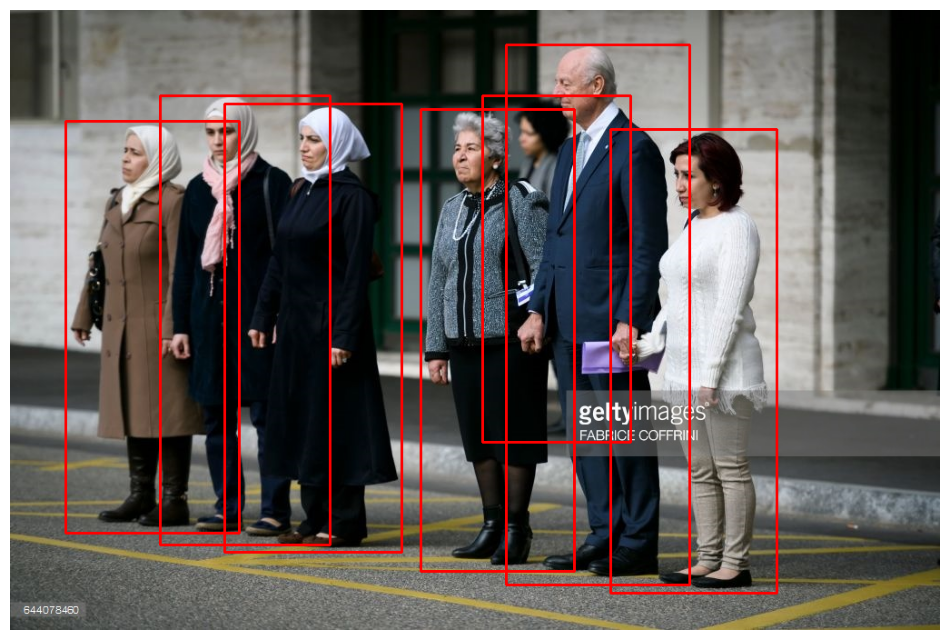

In [21]:
display = img.copy()
for person in record["gtboxes"]:
    if person["tag"] != "person":
        continue
    x,y,w,h = person["fbox"]
    cv2.rectangle(display,(x,y),(x+w,y+h),(255,0,0),2)
plt.figure(figsize=(12,12))
plt.imshow(display)
plt.axis("off")

###building yolo (converting imgs)

In [22]:
train_label_dir = train_image_dir.parent / "labels"
train_label_dir.mkdir(exist_ok=True)
print(train_label_dir)

/content/drive/MyDrive/SAR_Project/datasets/raw/CrowdHuman/CrowdHuman/train/labels


In [23]:
def crowdhuman_to_yolo(record, image_shape):
    h_img, w_img = image_shape[:2]
    labels = []
    for person in record["gtboxes"]:
        if person["tag"] != "person":
            continue
        x, y, w, h = person["fbox"]
        x_center = (x + w / 2) / w_img
        y_center = (y + h / 2) / h_img
        width = w / w_img
        height = h / h_img
        labels.append(f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")
    return labels

In [24]:
labels = crowdhuman_to_yolo(record, img.shape)
for l in labels[:5]:
    print(l)

0 0.152832 0.511713 0.186523 0.663250
0 0.252441 0.500732 0.182617 0.723280
0 0.325684 0.513177 0.190430 0.721816
0 0.523926 0.532943 0.165039 0.743777
0 0.587402 0.418009 0.159180 0.557833


In [26]:
from PIL import Image
from tqdm import tqdm
for record in tqdm(records):
    image_path = train_image_dir / f"{record['ID']}.jpg"
    label_path = train_label_dir / f"{record['ID']}.txt"
    if label_path.exists():
        continue
    try:
        with Image.open(image_path) as im:
            w_img, h_img = im.size
    except Exception:
        continue
    labels = []
    for person in record["gtboxes"]:
        if person["tag"] != "person":
            continue
        x, y, w, h = person["fbox"]
        xc = (x + w / 2) / w_img
        yc = (y + h / 2) / h_img
        bw = w / w_img
        bh = h / h_img
        labels.append(f"0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")
    with open(label_path, "w") as f:
        f.write("\n".join(labels))

100%|██████████| 15000/15000 [1:14:59<00:00,  3.33it/s]


####verifying conversion

In [27]:
from pathlib import Path
train_images = list((train_image_dir).glob("*.jpg"))
train_labels = list((train_label_dir).glob("*.txt"))
print(f"Images : {len(train_images)}")
print(f"Labels : {len(train_labels)}")

Images : 15000
Labels : 15000


In [28]:
empty = []
for f in train_label_dir.glob("*.txt"):
    if f.stat().st_size == 0:
        empty.append(f.name)
print("Empty labels:", len(empty))

Empty labels: 0


In [1]:
import random
import cv2
import matplotlib.pyplot as plt
sample = random.choice(train_images)
img = cv2.imread(str(sample))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]
label = train_label_dir / (sample.stem + ".txt")
with open(label) as f:
    for line in f:
        _, xc, yc, bw, bh = map(float, line.split())
        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255,0,0), 2)
plt.figure(figsize=(12,12))
plt.imshow(img)
plt.axis("off")

NameError: name 'train_images' is not defined